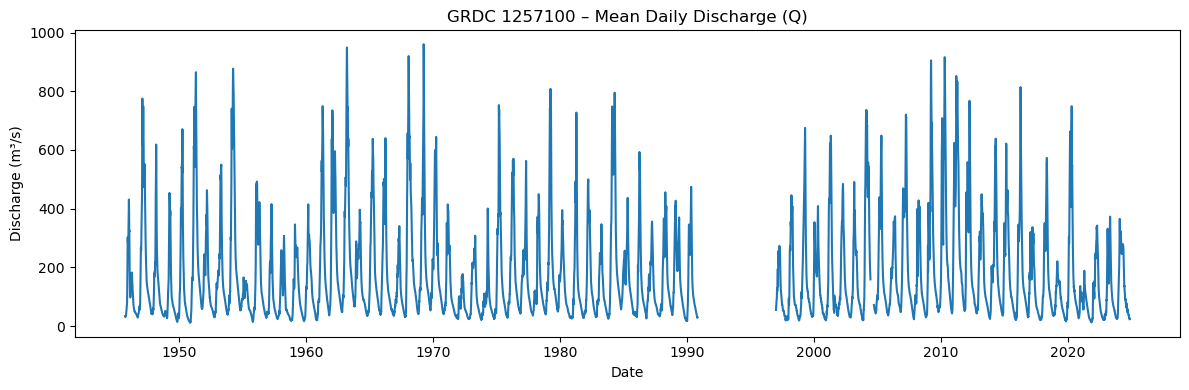

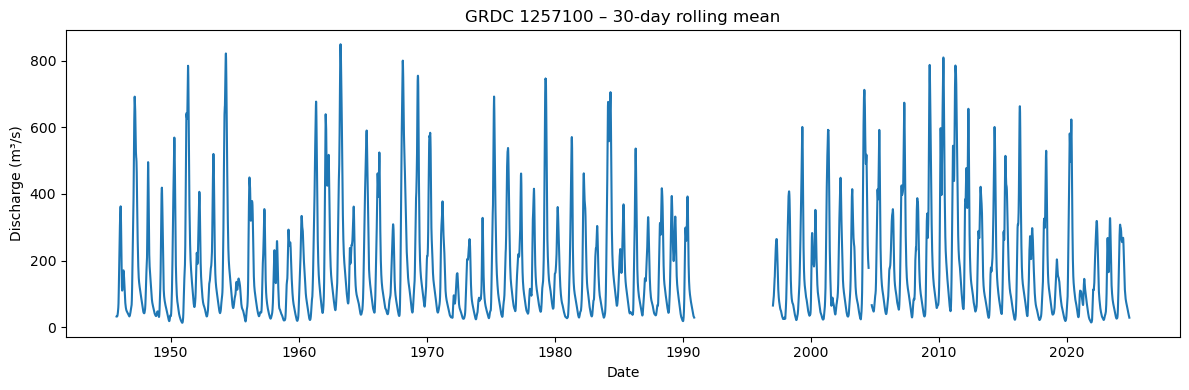

In [5]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# ---- file path (edit as needed) ----
path = Path("../GRDC_station_data/1257100_Q_Day.Cmd.txt")

# ---- read ----
df = pd.read_csv(
    path,
    sep=";",                 # semicolon-delimited
    comment="#",             # skip metadata/header lines starting with '#'
    skipinitialspace=True,   # handles "YYYY-MM-DD;hh:mm; Value" / padded numbers
    encoding="latin-1",      # avoids UnicodeDecodeError from superscripts like ³, ²
    na_values=[-999.000, "-999.000"],  # missing sentinel
)


# Clean column names (e.g., " Value" -> "Value")
df.columns = [c.strip() for c in df.columns]

# Ensure numeric values
df["Value"] = pd.to_numeric(df["Value"], errors="coerce")

# Build a datetime index.
# For daily data, hh:mm is often "--:--" (unknown), so map it to midnight.
time_str = df["hh:mm"].astype(str).replace({"--:--": "00:00"})
df["datetime"] = pd.to_datetime(
    df["YYYY-MM-DD"].astype(str) + " " + time_str,
    errors="coerce",
)

# Index by datetime and sort
df = df.dropna(subset=["datetime"]).set_index("datetime").sort_index()

q = df["Value"]  # discharge (m³/s)

# ---- plot 1: raw daily series ----
plt.figure(figsize=(12, 4))
plt.plot(q.index, q.values)
plt.xlabel("Date")
plt.ylabel("Discharge (m³/s)")
plt.title("GRDC 1257100 – Mean Daily Discharge (Q)")
plt.tight_layout()
plt.show()

# ---- plot 2 (optional): smoothed curve (30-day rolling mean) ----
plt.figure(figsize=(12, 4))
plt.plot(q.index, q.rolling(30, min_periods=10).mean())
plt.xlabel("Date")
plt.ylabel("Discharge (m³/s)")
plt.title("GRDC 1257100 – 30-day rolling mean")
plt.tight_layout()
plt.show()


---- METADATA ----
Altitude (m ASL): 1000
Catchment area (km²): 410000
Country: BW
Data Set Content: MEAN DAILY DISCHARGE (Q)
Data lines: 17973
Field delimiter: ;
Format: DOS-ASCII
GRDC-No.: 1357100
Last update: 2025-05-27
Latitude (DD): -18.283333
Longitude (DD): 21.8
Next downstream station: -
No. of years: 51
Owner of original data: Botswana - Department of Water and Sanitation
Remarks: 
River: OKAVANGO RIVER
Station: MOHEMBO/MTAEMBO (67932112)
Table Header: 
Time series: 1974-12 - 2024-02
Title: GRDC STATION DATA FILE
Unit of measure: m³/s
_date_max: 2024-02-17
_date_min: 1974-12-04
_file_mtime_utc: 2025-11-13 06:48:16+00:00
_file_name: 1357100_Q_Day.Cmd.txt
_file_size_bytes: 540409
_missing_values: 2014
_rows_read: 17973
file generation date: 2025-11-13


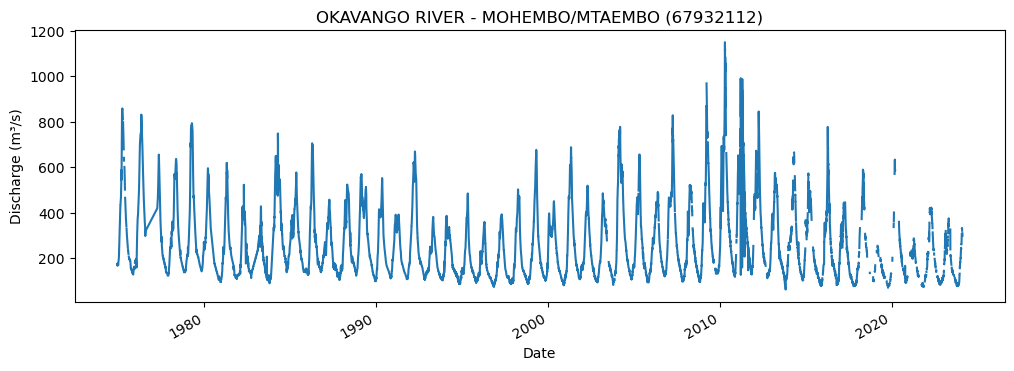

In [6]:
from __future__ import annotations

from pathlib import Path
import re
from datetime import date
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

MISSING_SENTINEL = -999.000


def extract_grdc_metadata(path: str | Path, encoding: str = "cp1252") -> dict:
    """
    Extract key/value metadata from the GRDC header (lines starting with '#').

    Notes:
      - This file contains superscript chars like 'm³/s' and 'km²'. In practice,
        'cp1252' or 'latin1' is usually safe for these GRDC text exports.
    """
    path = Path(path)
    meta: dict = {}
    header_lines: list[str] = []

    # Read header lines (start with '#') until the first non-header line
    with path.open("r", encoding=encoding, errors="replace") as f:
        for line in f:
            if not line.startswith("#"):
                break
            header_lines.append(line.rstrip("\n"))

    meta["_raw_header"] = header_lines  # keep if you want to inspect the full header

    # Parse "# Key: Value" lines
    kv_re = re.compile(r"^#\s*([^:]+):\s*(.*)$")
    for ln in header_lines:
        # Ignore indented comment lines (e.g. table header lines like "#     hh:mm - Time")
        if re.match(r"^#\s{2,}\S", ln):
            continue

        m = kv_re.match(ln)
        if not m:
            continue

        key = m.group(1).strip()
        val = re.sub(r"\s{2,}", " ", m.group(2).strip())  # collapse multiple spaces
        meta[key] = val

    # Light type coercions for common numeric/date fields
    def maybe_number(x: str):
        try:
            n = float(x)
            return int(n) if n.is_integer() else n
        except Exception:
            return x

    for k in [
        "GRDC-No.",
        "Next downstream station",
        "Data lines",
        "No. of years",
        "Latitude (DD)",
        "Longitude (DD)",
        "Catchment area (km²)",
        "Altitude (m ASL)",
    ]:
        if k in meta:
            meta[k] = maybe_number(str(meta[k]))

    for k in ["file generation date", "Last update"]:
        if k in meta:
            try:
                meta[k] = date.fromisoformat(str(meta[k]))
            except Exception:
                pass

    # Optional: include filesystem-level metadata too
    st = path.stat()
    meta["_file_name"] = path.name
    meta["_file_size_bytes"] = st.st_size
    meta["_file_mtime_utc"] = pd.to_datetime(st.st_mtime, unit="s", utc=True)

    return meta


def read_grdc_timeseries(path: str | Path, encoding: str = "cp1252") -> pd.DataFrame:
    """
    Read the GRDC data section into a DataFrame with a DatetimeIndex.
    """
    path = Path(path)

    df = pd.read_csv(path, sep=";", comment="#", encoding=encoding)
    df.columns = [c.strip() for c in df.columns]  # e.g. " Value" -> "Value"

    # Convert value and apply missing sentinel
    df["Value"] = pd.to_numeric(df["Value"], errors="coerce").replace(MISSING_SENTINEL, np.nan)

    # For daily values GRDC often uses "--:--" in the time column; treat it as midnight.
    time = df["hh:mm"].astype(str).str.strip().replace({"--:--": "00:00"})

    df["datetime"] = pd.to_datetime(
        df["YYYY-MM-DD"].astype(str).str.strip() + " " + time,
        errors="coerce",
    )

    df = df.dropna(subset=["datetime"]).set_index("datetime").sort_index()
    return df


def plot_grdc_timeseries(df: pd.DataFrame, meta: dict) -> None:
    """
    Simple timeseries plot.
    """
    unit = meta.get("Unit of measure", "")
    river = meta.get("River", "")
    station = meta.get("Station", "")
    title = " - ".join([x for x in [river, station] if x])

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(df.index, df["Value"])
    ax.set_xlabel("Date")
    ax.set_ylabel(f"Discharge ({unit})" if unit else "Discharge")
    if title:
        ax.set_title(title)
    fig.autofmt_xdate()
    plt.show()


if __name__ == "__main__":
    PATH = "../GRDC_station_data/1357100_Q_Day.Cmd.txt"  # <- change if needed

    meta = extract_grdc_metadata(PATH)
    df = read_grdc_timeseries(PATH)

    # Add a few derived metadata fields from the actual data read
    meta["_rows_read"] = len(df)
    meta["_missing_values"] = int(df["Value"].isna().sum())
    meta["_date_min"] = df.index.min().date().isoformat()
    meta["_date_max"] = df.index.max().date().isoformat()

    # Print metadata (skip the raw header unless you want it)
    print("---- METADATA ----")
    for k in sorted([k for k in meta.keys() if k != "_raw_header"]):
        print(f"{k}: {meta[k]}")

    # Plot
    plot_grdc_timeseries(df, meta)


Loaded 23 files
             source_file  grdc_no     station_name country        lat  \
0  1257100_Q_Day.Cmd.txt  1257100            RUNDU      NA -17.900000   
1  1257101_Q_Day.Cmd.txt  1257101            MUKWE      NA -18.033333   
2  1257200_Q_Day.Cmd.txt  1257200           OUSEMA      NA -21.216667   
3  1357100_Q_Day.Cmd.txt  1357100  MOHEMBO/MTAEMBO      BW -18.283333   
4  1357200_Q_Day.Cmd.txt  1357200    SHASHE BRIDGE      BW -20.016667   

         lon  
0  19.750000  
1  21.416667  
2  17.100000  
3  21.800000  
4  23.383333  


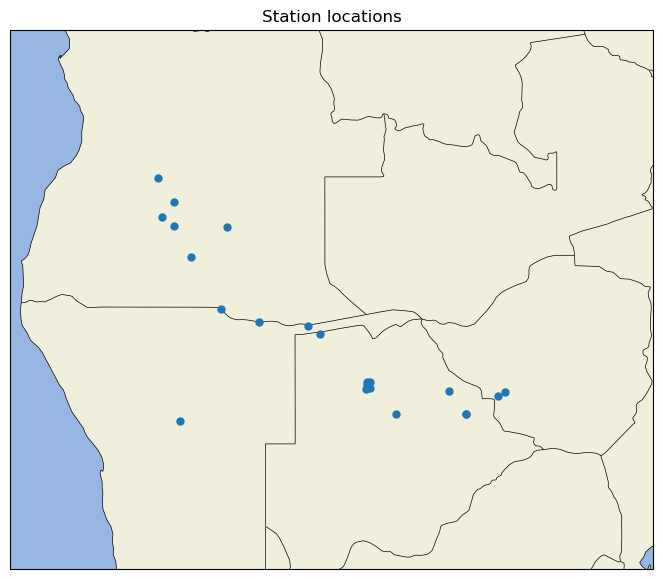

Saved timeseries plots to: grdc_timeseries_plots/


In [7]:
from __future__ import annotations

from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature


# Optional: only needed for the world basemap.
# If you already used geopandas for your map, keep it.
import geopandas as gpd


META_RE = re.compile(r"^#\s*(?P<key>[^:]+):\s*(?P<val>.*)\s*$")

def _to_float(x) -> float:
    """Robust float parsing (handles commas, whitespace, None)."""
    if x is None:
        return np.nan
    s = str(x).strip().replace(",", ".")
    return pd.to_numeric(s, errors="coerce")


def _parse_filename(fp: Path) -> dict:
    """
    Many GRDC files look like: 1257100_Q_Day.Cmd.txt
    We'll try to extract station id + variable tag from that.
    """
    m = re.match(r"^(?P<id>\d+)_(?P<tag>.+?)\.Cmd\.txt$", fp.name)
    if not m:
        return {"file_station_id": np.nan, "file_tag": fp.stem}
    return {
        "file_station_id": pd.to_numeric(m.group("id"), errors="coerce"),
        "file_tag": m.group("tag"),
    }


def read_grdc_cmd_file(fp: str | Path, encoding: str = "latin-1") -> tuple[dict, pd.DataFrame]:
    """
    Returns:
      meta: dict of metadata (raw + standardized fields)
      ts:   DataFrame with DatetimeIndex and numeric columns
    """
    fp = Path(fp)

    # --------- metadata (header) ----------
    meta_raw = {"source_file": fp.name, "source_path": str(fp)}
    meta_raw.update(_parse_filename(fp))

    with open(fp, "r", encoding=encoding, errors="replace") as f:
        for line in f:
            if not line.startswith("#"):
                continue
            m = META_RE.match(line)
            if m:
                meta_raw[m.group("key").strip()] = m.group("val").strip()

    # Standardize a few common keys (keep raw keys too)
    keymap = {
        "GRDC-No.": "grdc_no",
        "River": "river",
        "Station": "station_raw",
        "Country": "country",
        "Latitude (DD)": "lat",
        "Longitude (DD)": "lon",
        "Catchment area (km²)": "catchment_area_km2",
        "Catchment area (km�)": "catchment_area_km2",
        "Catchment area (km\xb2)": "catchment_area_km2",  # sometimes shows up like this
        "Altitude (m ASL)": "altitude_m",
        "file generation date": "file_generation_date",
        "Data lines": "data_lines",
    }
    meta = dict(meta_raw)  # copy

    for raw_k, std_k in keymap.items():
        if raw_k in meta_raw:
            meta[std_k] = meta_raw[raw_k]

    # Station name/code split like: "RUNDU (64932101)"
    if isinstance(meta.get("station_raw"), str):
        m = re.match(r"^(.*?)\s*\((.*?)\)\s*$", meta["station_raw"])
        if m:
            meta["station_name"] = m.group(1).strip()
            meta["station_code"] = m.group(2).strip()
        else:
            meta["station_name"] = meta["station_raw"].strip()

    # Numeric conversions (important for plotting)
    if "grdc_no" in meta:
        meta["grdc_no"] = pd.to_numeric(str(meta["grdc_no"]).strip(), errors="coerce")
    for k in ("lat", "lon", "catchment_area_km2", "altitude_m"):
        if k in meta:
            meta[k] = _to_float(meta[k])
    if "data_lines" in meta:
        meta["data_lines"] = pd.to_numeric(str(meta["data_lines"]).strip(), errors="coerce")

    # --------- time series table ----------
    # Use latin-1 to avoid UnicodeDecodeError from header chars (e.g., km²)
    df = pd.read_csv(
        fp,
        sep=";",
        comment="#",
        skip_blank_lines=True,
        dtype=str,
        encoding=encoding,
    )

    # Clean column names + strip whitespace
    df.columns = [c.strip() for c in df.columns]
    for c in df.columns:
        df[c] = df[c].astype(str).str.strip()

    date_col = df.columns[0]
    time_col = df.columns[1] if len(df.columns) >= 2 else None

    # IMPORTANT: specify format to avoid your warnings
    date = pd.to_datetime(df[date_col], format="%Y-%m-%d", errors="coerce")

    if time_col is not None and (df[time_col] != "--:--").any():
        # Files with actual times:
        t = df[time_col].replace({"--:--": "00:00"})
        dt = pd.to_datetime(df[date_col] + " " + t, format="%Y-%m-%d %H:%M", errors="coerce")
    else:
        # Daily files:
        dt = date

    # Convert remaining columns to numeric (and set missing flags to NaN)
    drop_cols = [date_col] + ([time_col] if time_col is not None else [])
    data_cols = [c for c in df.columns if c not in drop_cols]

    out = df[data_cols].replace(
        {"-999.000": np.nan, "-999": np.nan, "": np.nan, "nan": np.nan}
    )
    for c in data_cols:
        out[c] = pd.to_numeric(out[c], errors="coerce")

    out.insert(0, "datetime", dt)
    out = out.dropna(subset=["datetime"]).set_index("datetime").sort_index()

    return meta, out


def load_grdc_folder(folder: str | Path, pattern: str = "*.Cmd.txt") -> tuple[pd.DataFrame, dict]:
    """
    Returns:
      meta_df: one row per file
      ts_dict: dict keyed by (grdc_no, file_tag, source_file) -> DataFrame
    """
    folder = Path(folder)
    files = sorted(folder.glob(pattern))

    meta_rows = []
    ts_dict = {}

    for fp in files:
        meta, ts = read_grdc_cmd_file(fp)

        meta_rows.append(meta)

        # Key by station + tag + filename to avoid overwriting if multiple files per station
        grdc_no = meta.get("grdc_no", meta.get("file_station_id"))
        tag = meta.get("file_tag", fp.stem)
        ts_dict[(grdc_no, tag, fp.name)] = ts

    meta_df = pd.DataFrame(meta_rows)

    # Helpful: prefer grdc_no if pZresent
    if "grdc_no" in meta_df.columns:
        meta_df = meta_df.sort_values(["grdc_no", "source_file"], na_position="last").reset_index(drop=True)

    return meta_df, ts_dict

def plot_station_map(meta_df):
    stations = meta_df.dropna(subset=["lat", "lon"]).copy()

    fig, ax = plt.subplots(
        figsize=(10, 7),
        subplot_kw={"projection": ccrs.PlateCarree()}  
    )

    # Basemap features (no geopandas needed)
    ax.add_feature(cfeature.LAND, linewidth=0.2)
    ax.add_feature(cfeature.OCEAN, linewidth=0.2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)

    pad = 5
    lon_min = stations["lon"].min() - pad
    lon_max = stations["lon"].max() + pad
    lat_min = stations["lat"].min() - pad
    lat_max = stations["lat"].max() + pad

    #  now this works
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

    # IMPORTANT with cartopy: supply transform=
    ax.scatter(
        stations["lon"], stations["lat"],
        s=25,
        transform=ccrs.PlateCarree(),
        zorder=3
    )

    ax.set_title("Station locations")
    return fig, ax


def plot_timeseries_per_station(meta_df: pd.DataFrame, 
                                ts_dict: dict, 
                                out_dir: str | Path | None = None):
    """
    One figure per station (GRDC-No.). If multiple files per station, they are overlaid.
    """
    # Group dict entries by station id
    by_station = {}
    for (grdc_no, tag, fname), ts in ts_dict.items():
        by_station.setdefault(grdc_no, []).append((tag, fname, ts))

    if out_dir is not None:
        out_dir = Path(out_dir)
        out_dir.mkdir(parents=True, exist_ok=True)

    # Build a quick lookup for station name
    name_lookup = {}
    if "grdc_no" in meta_df.columns and "station_name" in meta_df.columns:
        for _, r in meta_df.dropna(subset=["grdc_no"]).iterrows():
            if pd.notna(r.get("station_name")):
                name_lookup[r["grdc_no"]] = r["station_name"]

    for grdc_no, series_list in by_station.items():
        
        fig, ax = plt.subplots(figsize=(14, 4))

        for (tag, fname, ts) in sorted(series_list, key=lambda x: str(x[0])):
            # Plot all numeric columns in this file
            numeric_cols = [c for c in ts.columns if pd.api.types.is_numeric_dtype(ts[c])]
            if not numeric_cols:
                continue
            ts[numeric_cols].plot(ax=ax, linewidth=0.8, label=[f"{tag}:{c}" for c in numeric_cols])

        station_name = name_lookup.get(grdc_no, "")
        title = f"GRDC {int(grdc_no) if pd.notna(grdc_no) else grdc_no}"
        if station_name:
            title += f" — {station_name}"
        ax.set_title(title)
        ax.set_xlabel("Date")
        ax.set_ylabel("Value")
        ax.grid(True, linewidth=0.2)

        # If there are many overlays, legend can get huge; toggle as you like:
        ax.legend(loc="best", fontsize=8, ncols=2)

        fig.tight_layout()

        if out_dir is not None:
            safe_id = "unknown" if pd.isna(grdc_no) else str(int(grdc_no))
            fig.savefig(out_dir / f"{safe_id}_timeseries.png", dpi=150)
            plt.close(fig)  # avoid 100s of open figures in notebooks


# --------------------
# RUN IT
# --------------------
DATA_DIR = Path("../GRDC_station_data")

meta_df, ts_dict = load_grdc_folder(DATA_DIR, pattern="*.Cmd.txt")

print(f"Loaded {len(meta_df)} files")
print(meta_df[["source_file", "grdc_no", "station_name", "country", "lat", "lon"]].head())

# Map (points should now appear)
fig, ax = plot_station_map(meta_df)
plt.show()

# Time series plots (set out_dir to save images)
plot_timeseries_per_station(meta_df, ts_dict, out_dir="grdc_timeseries_plots")
print("Saved timeseries plots to: grdc_timeseries_plots/")


In [8]:
import ee
import geemap
import geopandas as gpd

# --- EE init (authenticate once, then ee.Initialize() will work afterwards) ---
try:
    ee.Initialize()
except Exception:
    ee.Authenticate()
    ee.Initialize()

stations = meta_df
# --- build a ROI from your station extent (add padding so rivers aren't cut off) ---
min_lon = float(stations["lon"].min())
max_lon = float(stations["lon"].max())
min_lat = float(stations["lat"].min())
max_lat = float(stations["lat"].max())

pad_deg = 5.0  # tweak as needed
roi = ee.Geometry.Rectangle([min_lon - pad_deg, min_lat - pad_deg,
                            max_lon + pad_deg, max_lat + pad_deg])

# --- load & clip rivers ---
rivers_fc = (ee.FeatureCollection("WWF/HydroSHEDS/v1/FreeFlowingRivers")
             .filter(ee.Filter.lt('RIV_ORD', 7))
             .filterBounds(roi))

# OPTIONAL (recommended if it’s too dense): simplify geometry a bit (meters)
rivers_fc = rivers_fc.map(lambda f: f.simplify(500))

# --- convert to GeoDataFrame (function name depends on geemap version) ---
try:
    rivers_gdf = geemap.ee_to_geopandas(rivers_fc)
except AttributeError:
    rivers_gdf = geemap.ee_to_gdf(rivers_fc)  # older geemap versions

# set CRS (EE vectors are lon/lat)
rivers_gdf = rivers_gdf.set_crs("EPSG:4326", allow_override=True)



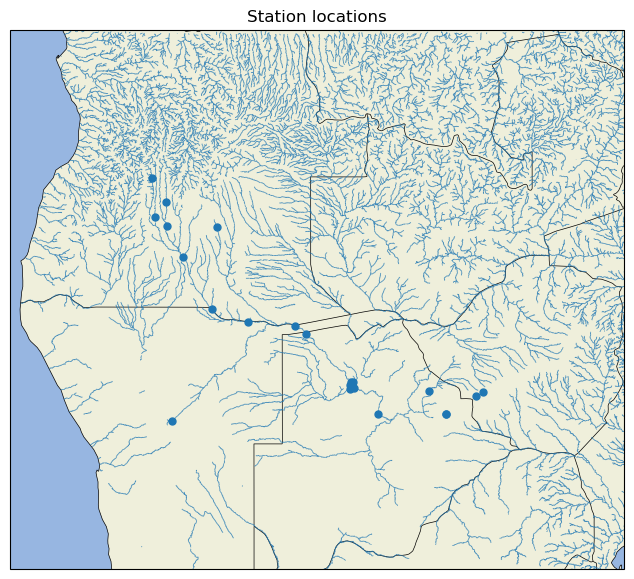

Saved timeseries plots to: grdc_timeseries_plots/


In [9]:
# Map (points should now appear)
fig, ax = plot_station_map(meta_df)

rivers_gdf.plot(
    ax=ax,
    linewidth=0.6,
    alpha=0.8,
    zorder=2
)

plt.show()

# Time series plots (set out_dir to save images)
plot_timeseries_per_station(meta_df, ts_dict, out_dir="grdc_timeseries_plots")
print("Saved timeseries plots to: grdc_timeseries_plots/")



In [11]:
# import sys
# !{sys.executable} -m pip install -U "plotly<6"


In [4]:
from pathlib import Path
import fiona

gpkg = Path("/Users/octaviacrompton/Projects/dswe-inman-lyons/notebooks/outputs/okavango_named_features.gpkg")

layers = fiona.listlayers(gpkg)
print("Layers in GPKG:")
for lyr in layers:
    print(" -", lyr)
 

Layers in GPKG:
 - osm_matches_points
 - osm_matches_lines
 - osm_matches_polygons
 - okavango_labels_matches
 - representative_points
 - channel_system_buffers


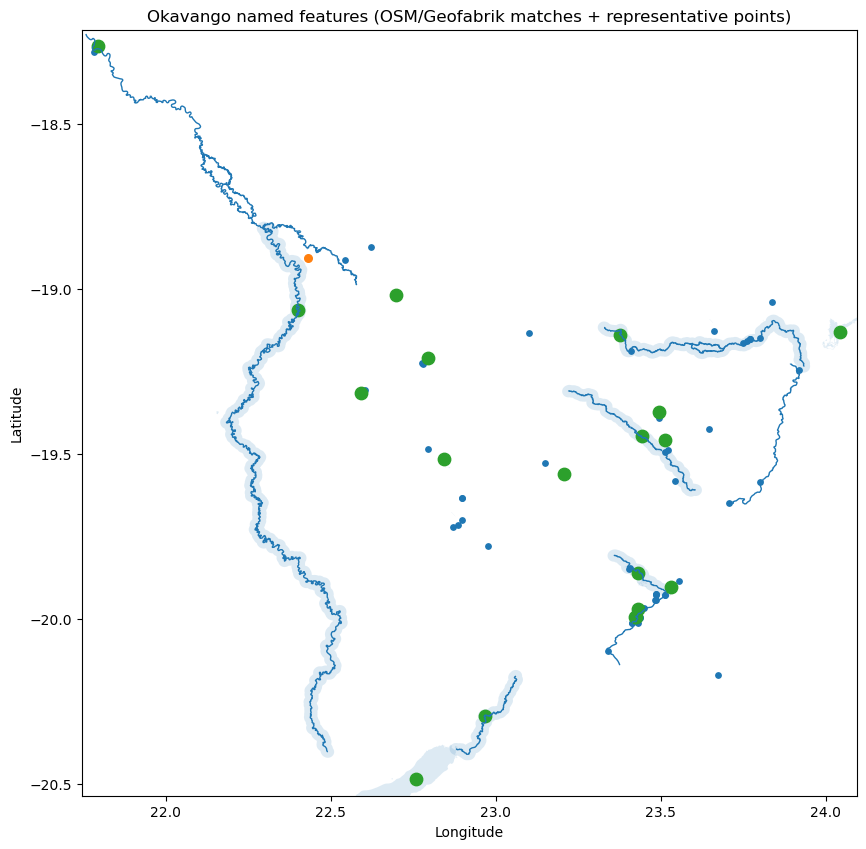

In [10]:

import geopandas as gpd
import matplotlib.pyplot as plt

def read_layer(gpkg_path, layer_name):
    try:
        return gpd.read_file(gpkg_path, layer=layer_name)
    except Exception as e:
        print(f"Could not read layer={layer_name}: {e}")
        return None

buffers = read_layer(gpkg, "channel_system_buffers")
polys   = read_layer(gpkg, "osm_matches_polygons")
lines   = read_layer(gpkg, "osm_matches_lines")
points  = read_layer(gpkg, "osm_matches_points")
reps    = read_layer(gpkg, "representative_points")
labels  = read_layer(gpkg, "okavango_labels_matches")  # optional

fig, ax = plt.subplots(figsize=(10, 10))

# Plot in a sensible order (background -> foreground)
if buffers is not None and not buffers.empty:
    buffers.plot(ax=ax, alpha=0.15)  # default color, transparent fill

if polys is not None and not polys.empty:
    polys.plot(ax=ax, alpha=0.15)

if lines is not None and not lines.empty:
    lines.plot(ax=ax, linewidth=1.0)

if points is not None and not points.empty:
    points.plot(ax=ax, markersize=15)

if labels is not None and not labels.empty:
    labels.plot(ax=ax, markersize=30)

if reps is not None and not reps.empty:
    reps.plot(ax=ax, markersize=80)


# Auto-zoom to data bounds (prefer reps; fallback to whatever exists)
for g in [reps, points, lines, polys, buffers]:
    if g is not None and not g.empty:
        minx, miny, maxx, maxy = g.total_bounds
        ax.set_xlim(minx - 0.05, maxx + 0.05)
        ax.set_ylim(miny - 0.05, maxy + 0.05)
        break

ax.set_title("Okavango named features (OSM/Geofabrik matches + representative points)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal", adjustable="box")
plt.show()

import matplotlib.pyplot as plt



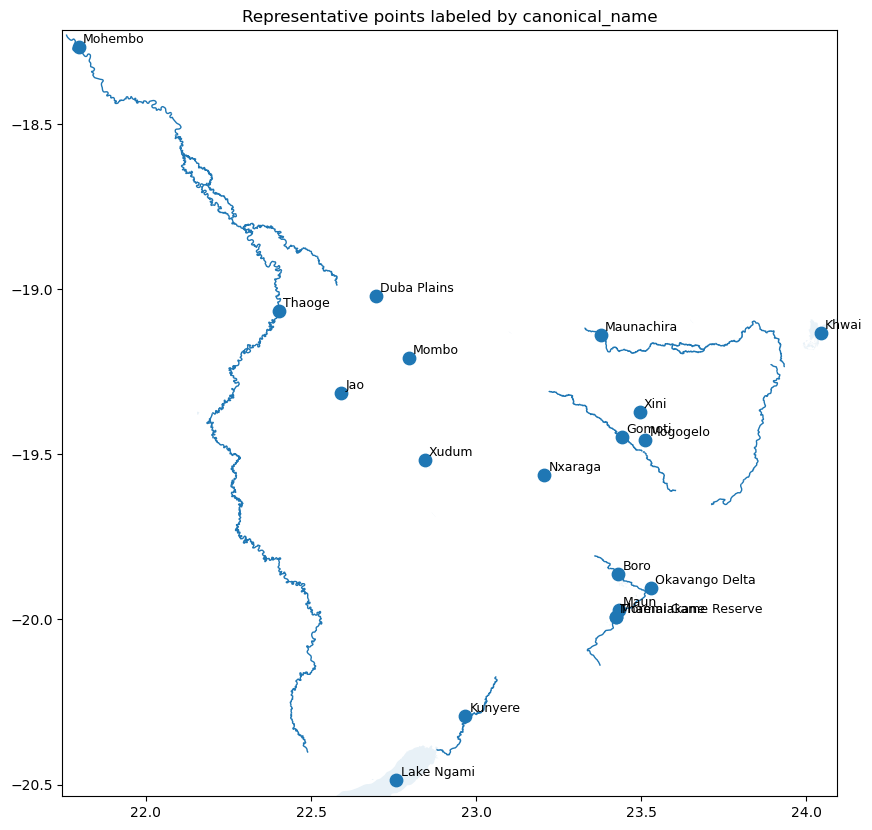

In [17]:
fig, ax = plt.subplots(figsize=(10, 10))

# Plot the same stack, but keep it simple
if polys is not None and not polys.empty:
    polys.plot(ax=ax, alpha=0.1)

if lines is not None and not lines.empty:
    lines.plot(ax=ax, linewidth=1.0)

if reps is not None and not reps.empty:
    reps.plot(ax=ax, markersize=80)

    # Add text labels
    for _, row in reps.iterrows():
        if row.geometry is None:
            continue
        x, y = row.geometry.x, row.geometry.y
        ax.annotate(
            text=row["canonical_name"],
            xy=(x, y),
            xytext=(3, 3),
            textcoords="offset points",
            fontsize=9
        )

# Zoom
if reps is not None and not reps.empty:
    minx, miny, maxx, maxy = reps.total_bounds
    ax.set_xlim(minx - 0.05, maxx + 0.05)
    ax.set_ylim(miny - 0.05, maxy + 0.05)

ax.set_title("Representative points labeled by canonical_name")
ax.set_aspect("equal", adjustable="box")
plt.show()


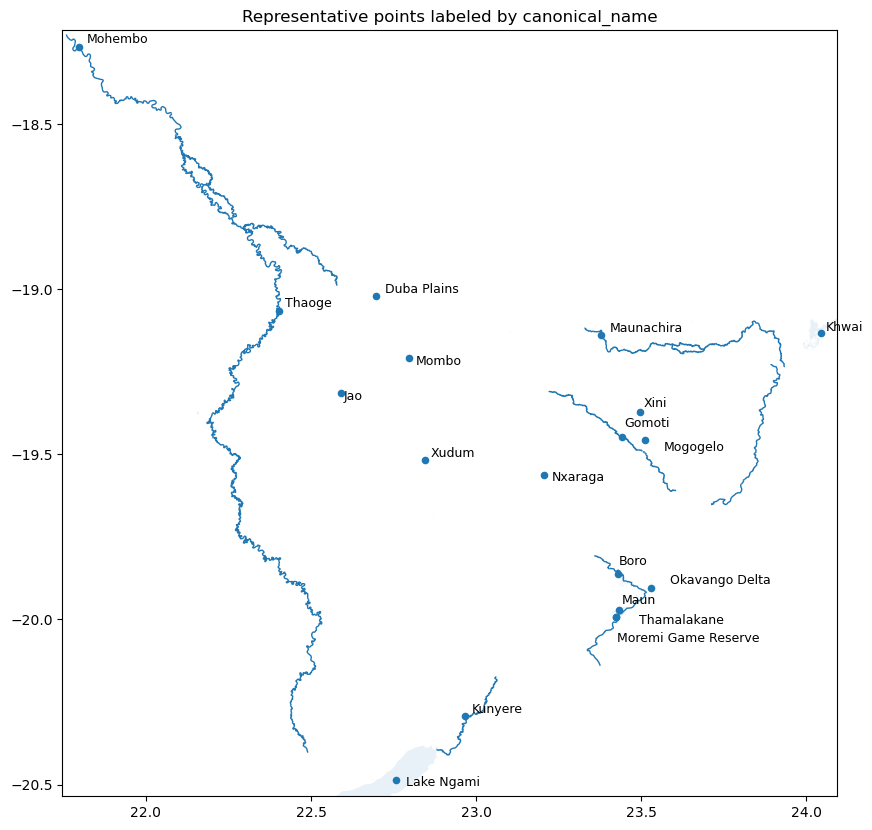

In [20]:
import matplotlib.pyplot as plt
from adjustText import adjust_text

fig, ax = plt.subplots(figsize=(10, 10))

# Plot the same stack, but keep it simple
if polys is not None and not polys.empty:
    polys.plot(ax=ax, alpha=0.1)

if lines is not None and not lines.empty:
    lines.plot(ax=ax, linewidth=1.0)

if reps is not None and not reps.empty:
    reps.plot(ax=ax, markersize=20)

    # Create text objects (one per point)
    texts = []
    for _, row in reps.iterrows():
        if row.geometry is None:
            continue
        x, y = row.geometry.x, row.geometry.y
        texts.append(ax.text(x, y, row["canonical_name"], fontsize=9))

    # Push labels away from each other (and optionally draw light leader lines)
    adjust_text(
        texts,
        ax=ax,
        expand_text=(1.2, 1.2),
        expand_points=(1.4, 1.4),
        arrowprops=dict(arrowstyle="-", lw=0.),
    )

# Zoom
if reps is not None and not reps.empty:
    minx, miny, maxx, maxy = reps.total_bounds
    ax.set_xlim(minx - 0.05, maxx + 0.05)
    ax.set_ylim(miny - 0.05, maxy + 0.05)

ax.set_title("Representative points labeled by canonical_name")
ax.set_aspect("equal", adjustable="box")
plt.show()


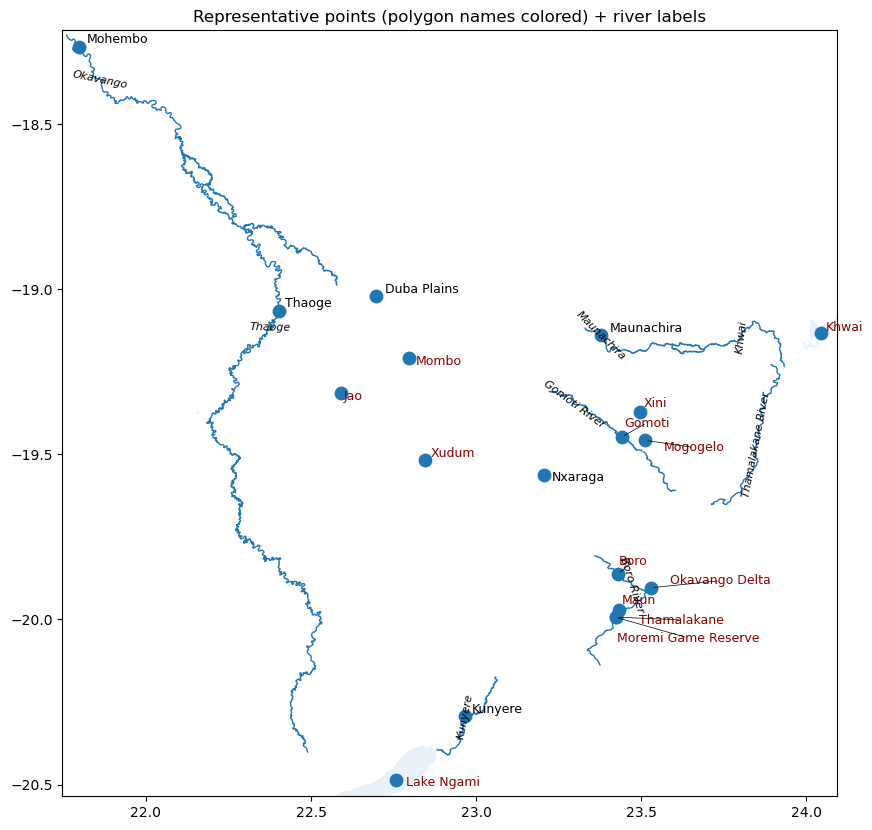

In [29]:
import math
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.transforms import Bbox

# -----------------------------
# Helpers
# -----------------------------
def _pad_bbox(bb: Bbox, pad_px: float = 2.0) -> Bbox:
    return Bbox.from_extents(bb.x0 - pad_px, bb.y0 - pad_px, bb.x1 + pad_px, bb.y1 + pad_px)

def _longest_linestring(geom):
    """Return a LineString from (Multi)LineString by taking the longest component."""
    if geom is None:
        return None
    gt = geom.geom_type
    if gt == "LineString":
        return geom
    if gt == "MultiLineString":
        return max(list(geom.geoms), key=lambda g: g.length) if len(geom.geoms) else None
    return None

def _point_and_angle_on_line(line, frac: float, eps: float = 0.01):
    """Get a point (x,y) on a line at fraction frac and a local text angle (degrees)."""
    if line is None or line.length == 0:
        return None

    frac = max(0.01, min(0.99, frac))
    p1 = line.interpolate(frac, normalized=True)

    frac2 = min(0.99, frac + eps)
    p2 = line.interpolate(frac2, normalized=True)

    dx = p2.x - p1.x
    dy = p2.y - p1.y
    if dx == 0 and dy == 0:
        angle = 0.0
    else:
        angle = math.degrees(math.atan2(dy, dx))

    # Keep text from being upside down
    if angle > 90:
        angle -= 180
    elif angle < -90:
        angle += 180

    return p1.x, p1.y, angle

def _place_line_label_greedy(
    ax,
    fig,
    geom,
    label: str,
    existing_bboxes: list,
    fontsize: int = 8,
    pad_px: float = 2.0,
    fractions=(0.5, 0.4, 0.6, 0.3, 0.7, 0.2, 0.8),
):
    """
    Place one label on a (multi)line geometry, trying multiple fractions until it doesn't
    overlap existing label bboxes. Adds its bbox to existing_bboxes.
    """
    line = _longest_linestring(geom)
    if line is None or line.length == 0:
        return None

    renderer = fig.canvas.get_renderer()

    # Create once, then move it around
    # (Don't set a color unless you want one; default will be used.)
    txt = ax.text(
        0, 0, label,
        fontsize=fontsize,
        fontstyle="italic",
        ha="center",
        va="center",
        rotation=0,
        rotation_mode="anchor",
    )

    for frac in fractions:
        res = _point_and_angle_on_line(line, frac=frac, eps=0.01)
        if res is None:
            continue
        x, y, ang = res

        txt.set_position((x, y))
        txt.set_rotation(ang)

        fig.canvas.draw()
        bb = _pad_bbox(txt.get_window_extent(renderer=renderer), pad_px=pad_px)

        if all(not bb.overlaps(other) for other in existing_bboxes):
            existing_bboxes.append(bb)
            return txt

    # If we couldn't avoid overlap, keep it at the default fraction (0.5) anyway
    res = _point_and_angle_on_line(line, frac=0.5, eps=0.01)
    if res is not None:
        x, y, ang = res
        txt.set_position((x, y))
        txt.set_rotation(ang)
        fig.canvas.draw()
        bb = _pad_bbox(txt.get_window_extent(renderer=renderer), pad_px=pad_px)
        existing_bboxes.append(bb)

    return txt


# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 10))

# Base layers
if polys is not None and not polys.empty:
    polys.plot(ax=ax, alpha=0.1)

if lines is not None and not lines.empty:
    lines.plot(ax=ax, linewidth=1.0)

if reps is not None and not reps.empty:
    reps.plot(ax=ax, markersize=80)

# Determine which canonical names have polygon geometries (for label coloring)
poly_names = set()
if polys is not None and (not polys.empty) and ("canonical_name" in polys.columns):
    poly_names = set(polys["canonical_name"].dropna().unique())

# ---- 1) Label representative points (polygon names in different font color), de-overlapped ----
point_texts = []
if reps is not None and not reps.empty:
    try:
        # Best: adjustText
        from adjustText import adjust_text

        for _, row in reps.iterrows():
            if row.geometry is None:
                continue
            x, y = row.geometry.x, row.geometry.y
            name = str(row["canonical_name"])

            # Only specify a color for polygon-names; otherwise use default
            if name in poly_names:
                t = ax.text(x, y, name, fontsize=9, color="darkred")
            else:
                t = ax.text(x, y, name, fontsize=9)

            point_texts.append(t)

        adjust_text(
            point_texts,
            ax=ax,
            expand_text=(1.2, 1.2),
            expand_points=(1.4, 1.4),
            arrowprops=dict(arrowstyle="-", lw=0.5),
        )

    except ImportError:
        # Fallback: simple greedy offsets (no extra deps)
        fig.canvas.draw()
        renderer = fig.canvas.get_renderer()
        placed_bboxes = []

        # offsets in points
        offsets = [(3, 3)]
        for r in range(5, 55, 5):
            offsets.extend([
                ( r,  r), ( r, -r), (-r,  r), (-r, -r),
                ( 0,  r), ( 0, -r), ( r,  0), (-r,  0),
            ])

        for _, row in reps.iterrows():
            if row.geometry is None:
                continue
            x, y = row.geometry.x, row.geometry.y
            name = str(row["canonical_name"])

            # color only for polygon names
            kwargs = dict(fontsize=9)
            if name in poly_names:
                kwargs["color"] = "darkred"

            ann = ax.annotate(
                name,
                xy=(x, y),
                xytext=(3, 3),
                textcoords="offset points",
                arrowprops=dict(arrowstyle="-", lw=0.5),
                **kwargs
            )

            placed = False
            for dx, dy in offsets:
                ann.set_position((dx, dy))
                fig.canvas.draw()
                bb = _pad_bbox(ann.get_window_extent(renderer=renderer), pad_px=2)
                if all(not bb.overlaps(other) for other in placed_bboxes):
                    placed_bboxes.append(bb)
                    placed = True
                    break

            if not placed:
                fig.canvas.draw()
                bb = _pad_bbox(ann.get_window_extent(renderer=renderer), pad_px=2)
                placed_bboxes.append(bb)

            point_texts.append(ann)

# ---- 2) Collect bboxes of placed point labels to avoid river-label collisions ----
fig.canvas.draw()
renderer = fig.canvas.get_renderer()
existing_bboxes = []
for t in point_texts:
    try:
        existing_bboxes.append(_pad_bbox(t.get_window_extent(renderer=renderer), pad_px=2))
    except Exception:
        pass

# ---- 3) Label the rivers (linework) ----
if lines is not None and not lines.empty and "canonical_name" in lines.columns:
    # Make one geometry per canonical_name to avoid labeling tons of segments
    # Also compute a "best" label string from the original OSM 'name' where possible
    label_lookup = {}
    if "name" in lines.columns:
        tmp = lines.dropna(subset=["canonical_name", "name"]).copy()
        if not tmp.empty:
            label_lookup = (
                tmp.groupby("canonical_name")["name"]
                   .apply(lambda s: s.value_counts().idxmax())
                   .to_dict()
            )

    lines_diss = lines.dissolve(by="canonical_name", as_index=False)

    for _, row in lines_diss.iterrows():
        if row.geometry is None:
            continue

        canon = str(row["canonical_name"])
        label = label_lookup.get(canon, canon)  # prefer OSM name if available

        _place_line_label_greedy(
            ax=ax,
            fig=fig,
            geom=row.geometry,
            label=label,
            existing_bboxes=existing_bboxes,
            fontsize=8,
            pad_px=2.0,
            fractions=(0.5, 0.4, 0.6, 0.3, 0.7, 0.2, 0.8),
        )

# Zoom
if reps is not None and not reps.empty:
    minx, miny, maxx, maxy = reps.total_bounds
    ax.set_xlim(minx - 0.05, maxx + 0.05)
    ax.set_ylim(miny - 0.05, maxy + 0.05)

ax.set_title("Representative points (polygon names colored) + river labels")
ax.set_aspect("equal", adjustable="box")
plt.show()


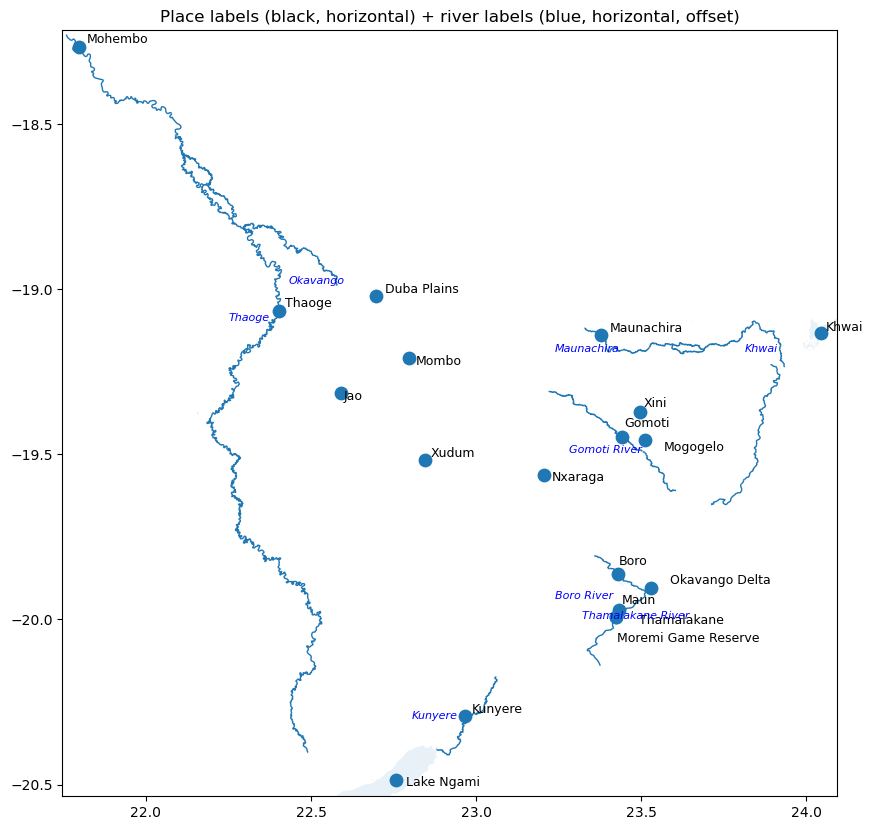

In [32]:
import math
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.transforms import Bbox

# -----------------------------
# TUNABLES
# -----------------------------
RIVER_LABEL_FONT_SIZE = 8
RIVER_LABEL_COLOR = "blue"
PLACE_LABEL_FONT_SIZE = 9
PLACE_LABEL_COLOR = "black"

# Put river labels farther from the line (in points)
RIVER_LABEL_OFFSETS_PTS = (14, -14, 22, -22, 30, -30)
PAD_PX = 2

# If you want to avoid duplicating names (e.g., "Boro" as a place label AND a river label),
# set this True.
SUPPRESS_PLACE_LABELS_FOR_RIVER_NAMES = False


# -----------------------------
# Helpers
# -----------------------------
def _pad_bbox(bb: Bbox, pad_px: float = 2.0) -> Bbox:
    return Bbox.from_extents(bb.x0 - pad_px, bb.y0 - pad_px, bb.x1 + pad_px, bb.y1 + pad_px)

def _pick_linestring_near_rep(multiline_or_line, rep_pt):
    """Pick the component LineString closest to rep_pt (UTM)."""
    if multiline_or_line is None:
        return None, None

    gt = multiline_or_line.geom_type
    if gt == "LineString":
        return multiline_or_line, 0

    if gt == "MultiLineString":
        parts = list(multiline_or_line.geoms)
        if not parts:
            return None, None
        if rep_pt is None:
            idx = max(range(len(parts)), key=lambda i: parts[i].length)
            return parts[idx], idx
        idx = min(range(len(parts)), key=lambda i: parts[i].distance(rep_pt))
        return parts[idx], idx

    return None, None

def _angle_at_fraction(line, frac: float, eps: float = 0.01):
    """
    Compute local line direction angle (degrees) at fraction frac.
    We use this ONLY to choose a perpendicular offset direction,
    NOT to rotate text (labels remain horizontal).
    """
    if line is None or line.length == 0:
        return None

    frac = max(0.02, min(0.98, frac))
    p1 = line.interpolate(frac, normalized=True)
    p2 = line.interpolate(min(0.99, frac + eps), normalized=True)

    dx = p2.x - p1.x
    dy = p2.y - p1.y
    if dx == 0 and dy == 0:
        ang = 0.0
    else:
        ang = math.degrees(math.atan2(dy, dx))

    # keep normal direction stable (angle can be anything; rotation won't use it)
    return p1.x, p1.y, ang

def _fractions_around(base: float, steps=(0.0, -0.08, 0.08, -0.16, 0.16, -0.24, 0.24)):
    fracs = []
    for s in steps:
        f = base + s
        if 0.02 < f < 0.98:
            fracs.append(f)
    return fracs if fracs else [0.5, 0.4, 0.6]

def place_river_label_offset_near_rep_horizontal(
    ax,
    fig,
    geom_wgs,
    geom_utm,
    rep_pt_utm,
    label,
    existing_bboxes,
    fontsize=8,
    color="blue",
    pad_px=2,
    offsets_pts=(14, -14, 22, -22),
):
    """
    Place a river label near (but not on) the river line:
      - choose the MultiLineString component closest to rep point (UTM)
      - find a point along that component near rep point
      - offset label perpendicular to local line direction (in points)
      - label is ALWAYS HORIZONTAL (rotation=0)
      - avoid overlaps with existing_bboxes
    """
    if geom_wgs is None or geom_utm is None:
        return None

    # Choose the branch nearest the rep point (in UTM)
    line_utm, idx = _pick_linestring_near_rep(geom_utm, rep_pt_utm)
    if line_utm is None or line_utm.length == 0:
        return None

    # Base fraction near rep point
    base_frac = (line_utm.project(rep_pt_utm) / line_utm.length) if rep_pt_utm is not None else 0.5

    # Get corresponding WGS branch using same component index
    if geom_wgs.geom_type == "LineString":
        line_wgs = geom_wgs
    elif geom_wgs.geom_type == "MultiLineString":
        parts = list(geom_wgs.geoms)
        if not parts:
            return None
        if idx is not None and idx < len(parts):
            line_wgs = parts[idx]
        else:
            line_wgs = max(parts, key=lambda g: g.length)
    else:
        return None

    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()

    for frac in _fractions_around(base_frac):
        res = _angle_at_fraction(line_wgs, frac=frac, eps=0.01)
        if res is None:
            continue
        x, y, ang = res

        # Perpendicular direction for offset (but keep label horizontal)
        normal_rad = math.radians(ang + 90.0)

        for o in offsets_pts:
            dx = o * math.cos(normal_rad)
            dy = o * math.sin(normal_rad)

            ann = ax.annotate(
                label,
                xy=(x, y),
                xytext=(dx, dy),
                textcoords="offset points",
                ha="center",
                va="center",
                fontsize=fontsize,
                color=color,
                rotation=0,               # <- ALWAYS HORIZONTAL
                rotation_mode="anchor",
                fontstyle="italic",
            )

            fig.canvas.draw()
            bb = _pad_bbox(ann.get_window_extent(renderer=renderer), pad_px=pad_px)

            if all(not bb.overlaps(other) for other in existing_bboxes):
                existing_bboxes.append(bb)
                return ann

            ann.remove()

    # If nothing fits, place anyway at base_frac with first offset
    res = _angle_at_fraction(line_wgs, frac=base_frac, eps=0.01)
    if res is None:
        return None
    x, y, ang = res
    normal_rad = math.radians(ang + 90.0)
    o = offsets_pts[0]
    dx = o * math.cos(normal_rad)
    dy = o * math.sin(normal_rad)

    ann = ax.annotate(
        label,
        xy=(x, y),
        xytext=(dx, dy),
        textcoords="offset points",
        ha="center",
        va="center",
        fontsize=fontsize,
        color=color,
        rotation=0,                   # <- ALWAYS HORIZONTAL
        rotation_mode="anchor",
        fontstyle="italic",
    )
    fig.canvas.draw()
    bb = _pad_bbox(ann.get_window_extent(renderer=renderer), pad_px=pad_px)
    existing_bboxes.append(bb)
    return ann


# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 10))

if polys is not None and not polys.empty:
    polys.plot(ax=ax, alpha=0.1)

if lines is not None and not lines.empty:
    lines.plot(ax=ax, linewidth=1.0)

if reps is not None and not reps.empty:
    reps.plot(ax=ax, markersize=80)

# Identify which canonical_names are "river-like" (appear in line layer)
river_like = set()
if lines is not None and (not lines.empty) and ("canonical_name" in lines.columns):
    river_like = set(lines["canonical_name"].dropna().unique())

# ---- Place labels (black), de-overlapped ----
place_texts = []
if reps is not None and not reps.empty:
    reps_to_label = reps.copy()
    if SUPPRESS_PLACE_LABELS_FOR_RIVER_NAMES:
        reps_to_label = reps_to_label[~reps_to_label["canonical_name"].isin(river_like)].copy()

    try:
        from adjustText import adjust_text

        for _, row in reps_to_label.iterrows():
            if row.geometry is None:
                continue
            x, y = row.geometry.x, row.geometry.y
            place_texts.append(
                ax.text(
                    x, y,
                    str(row["canonical_name"]),
                    fontsize=PLACE_LABEL_FONT_SIZE,
                    color=PLACE_LABEL_COLOR,
                )
            )

        adjust_text(
            place_texts,
            ax=ax,
            expand_text=(1.2, 1.2),
            expand_points=(1.4, 1.4),
            # no arrows keeps it clean; turn on if you want leader lines:
            # arrowprops=dict(arrowstyle="-", lw=0.5),
        )

    except ImportError:
        # fallback: labels without de-overlap
        for _, row in reps_to_label.iterrows():
            if row.geometry is None:
                continue
            x, y = row.geometry.x, row.geometry.y
            place_texts.append(ax.text(x, y, str(row["canonical_name"]), fontsize=PLACE_LABEL_FONT_SIZE, color=PLACE_LABEL_COLOR))

# collect bboxes for collision avoidance with river labels
fig.canvas.draw()
renderer = fig.canvas.get_renderer()
existing_bboxes = []
for t in place_texts:
    try:
        existing_bboxes.append(_pad_bbox(t.get_window_extent(renderer=renderer), pad_px=PAD_PX))
    except Exception:
        pass

# ---- River labels (blue), horizontal, offset from rivers ----
if lines is not None and not lines.empty and "canonical_name" in lines.columns:
    # Prefer the most common original OSM 'name' per canonical_name if available
    label_lookup = {}
    if "name" in lines.columns:
        tmp = lines.dropna(subset=["canonical_name", "name"]).copy()
        if not tmp.empty:
            label_lookup = (
                tmp.groupby("canonical_name")["name"]
                   .apply(lambda s: s.value_counts().idxmax())
                   .to_dict()
            )

    lines_diss = lines.dissolve(by="canonical_name", as_index=False)

    # For branch-aware placement we need UTM copies and a rep-point lookup
    CRS_UTM34S = "EPSG:32734"
    lines_diss_utm = lines_diss.to_crs(CRS_UTM34S)

    reps_utm = reps.to_crs(CRS_UTM34S) if reps is not None and not reps.empty else None
    rep_pt_utm_lookup = {}
    if reps_utm is not None and not reps_utm.empty:
        rep_pt_utm_lookup = {r["canonical_name"]: r.geometry for _, r in reps_utm.iterrows()}

    for i, row in lines_diss.iterrows():
        geom_wgs = row.geometry
        geom_utm = lines_diss_utm.loc[i].geometry

        canon = str(row["canonical_name"])
        label = label_lookup.get(canon, canon)

        rep_pt_utm = rep_pt_utm_lookup.get(canon)

        place_river_label_offset_near_rep_horizontal(
            ax=ax,
            fig=fig,
            geom_wgs=geom_wgs,
            geom_utm=geom_utm,
            rep_pt_utm=rep_pt_utm,
            label=label,
            existing_bboxes=existing_bboxes,
            fontsize=RIVER_LABEL_FONT_SIZE,
            color=RIVER_LABEL_COLOR,
            pad_px=PAD_PX,
            offsets_pts=RIVER_LABEL_OFFSETS_PTS,
        )

# Zoom
if reps is not None and not reps.empty:
    minx, miny, maxx, maxy = reps.total_bounds
    ax.set_xlim(minx - 0.05, maxx + 0.05)
    ax.set_ylim(miny - 0.05, maxy + 0.05)

ax.set_title("Place labels (black, horizontal) + river labels (blue, horizontal, offset)")
ax.set_aspect("equal", adjustable="box")
plt.show()


In [33]:
def plot_canonical(name: str, pad_deg: float = 0.08):
    fig, ax = plt.subplots(figsize=(9, 9))

    def subselect(gdf):
        if gdf is None or gdf.empty:
            return None
        if "canonical_name" not in gdf.columns:
            return None
        s = gdf[gdf["canonical_name"] == name].copy()
        return s if not s.empty else None

    p_polys  = subselect(polys)
    p_lines  = subselect(lines)
    p_points = subselect(points)
    p_reps   = reps[reps["canonical_name"] == name].copy() if reps is not None and not reps.empty else None

    if p_polys is not None:
        p_polys.plot(ax=ax, alpha=0.2)

    if p_lines is not None:
        p_lines.plot(ax=ax, linewidth=2.0)

    if p_points is not None:
        p_points.plot(ax=ax, markersize=40)

    if p_reps is not None and not p_reps.empty:
        p_reps.plot(ax=ax, markersize=120)
        for _, row in p_reps.iterrows():
            x, y = row.geometry.x, row.geometry.y
            ax.annotate(row["canonical_name"], (x, y), xytext=(3, 3), textcoords="offset points")

    # Zoom to whatever exists
    for g in [p_polys, p_lines, p_points, p_reps]:
        if g is not None and not g.empty:
            minx, miny, maxx, maxy = g.total_bounds
            ax.set_xlim(minx - pad_deg, maxx + pad_deg)
            ax.set_ylim(miny - pad_deg, maxy + pad_deg)
            break

    ax.set_title(f"Canonical feature: {name}")
    ax.set_aspect("equal", adjustable="box")
    plt.show()

# Example:
# plot_canonical("Boro")
# plot_canonical("Gomoti")
# plot_canonical("Thamalakane")


In [39]:
import folium
import geopandas as gpd

# Tweak these
POINT_RADIUS = 3     # for `points`
REPS_RADIUS  = 10    # for `reps` (usually larger so it stands out)

center = reps.geometry.unary_union.centroid
m = folium.Map(location=[center.y, center.x], zoom_start=8, tiles="OpenStreetMap")

# Polygons bottom
if polys is not None and not polys.empty:
    m = polys.explore(
        m=m,
        tooltip=["source_layer", "name"],
        style_kwds={"fillOpacity": 0.1},
        legend=False,
    )

# Lines next
if lines is not None and not lines.empty:
    m = lines.explore(
        m=m,
        tooltip=["source_layer", "name"],
        style_kwds={"weight": 2},
        legend=False,
    )

# Points above lines
if points is not None and not points.empty:
    m = points.explore(
        m=m,
        tooltip=["source_layer", "name"],
        legend=False,
        marker_kwds={"radius": POINT_RADIUS},
    )

# Reps topmost + legend
if reps is not None and not reps.empty:
    m = reps.explore(
        m=m,
        column="canonical_name",
        tooltip=["canonical_name", "source_layer", "orig_name"],
        legend=True,
        marker_kwds={"radius": REPS_RADIUS},
    )

folium.LayerControl(collapsed=True).add_to(m)
m


In [40]:
# https://chatgpt.com/c/69543b7e-a620-8332-a6d2-37862cf9a31c

Last edited: 2026-03-08
